Tabla VD por experimento guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/tabla_vd_por_experimento.csv

Tabla VD con medias de experimentos guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/tabla_vd_medias_experimentos.csv



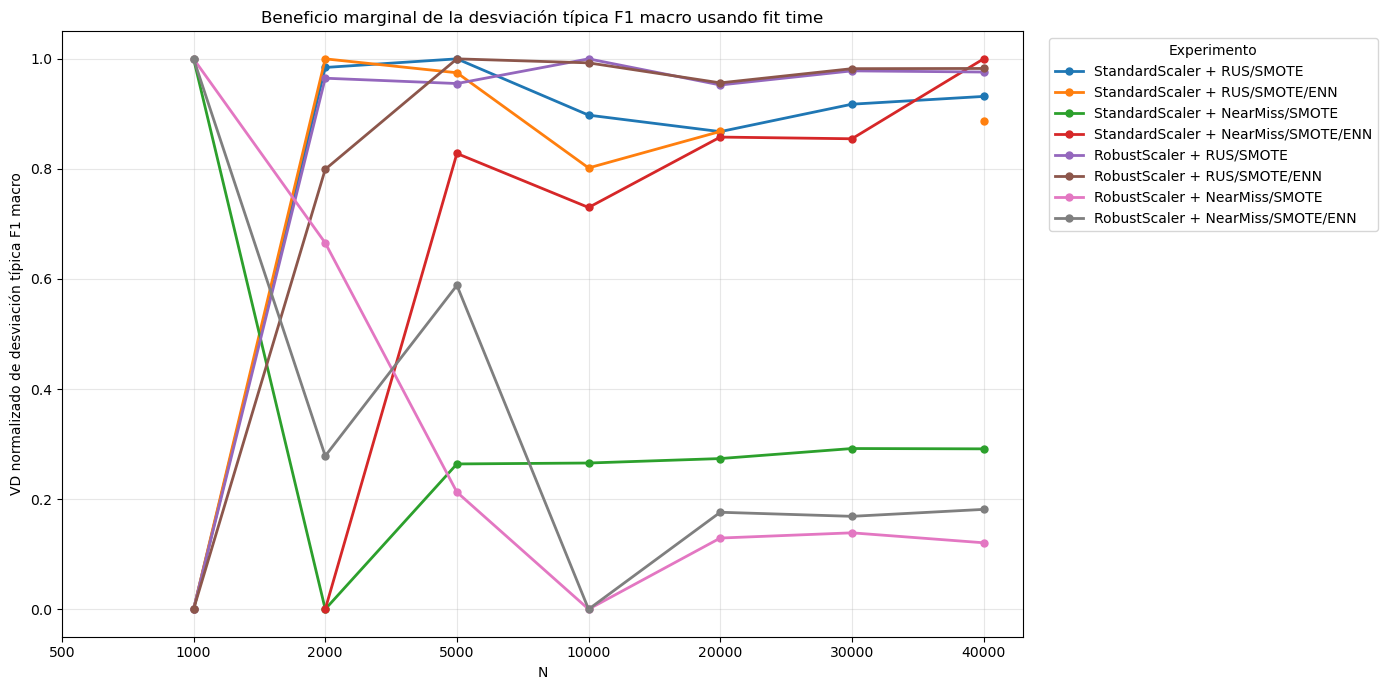

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_std_f1_macro_con_fit_time_por_experimento.pdf



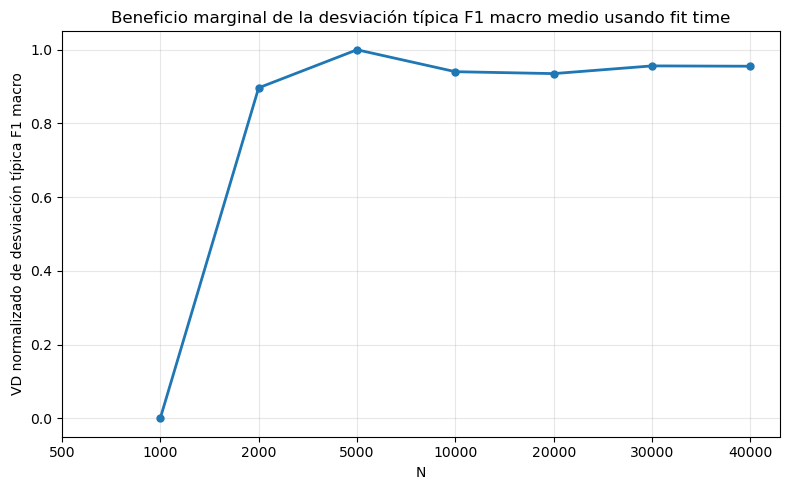

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_std_f1_macro_medio_con_fit_time.pdf



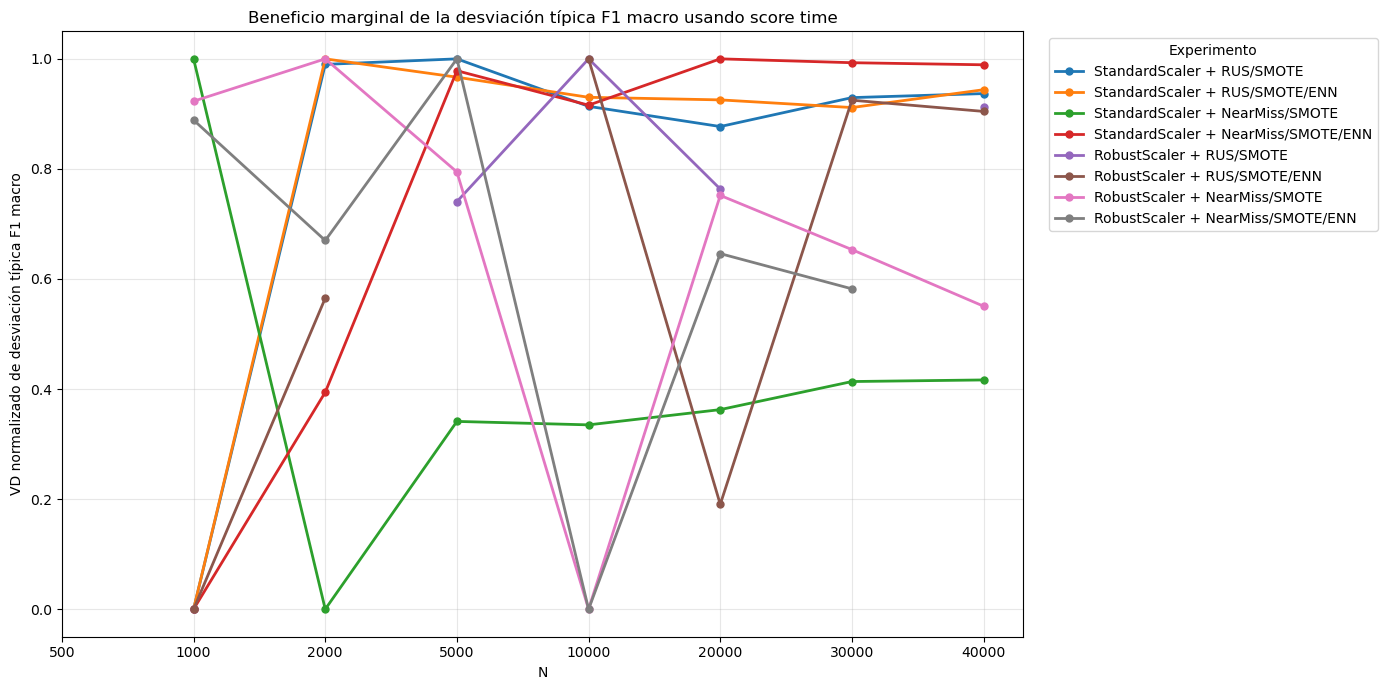

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_std_f1_macro_con_score_time_por_experimento.pdf



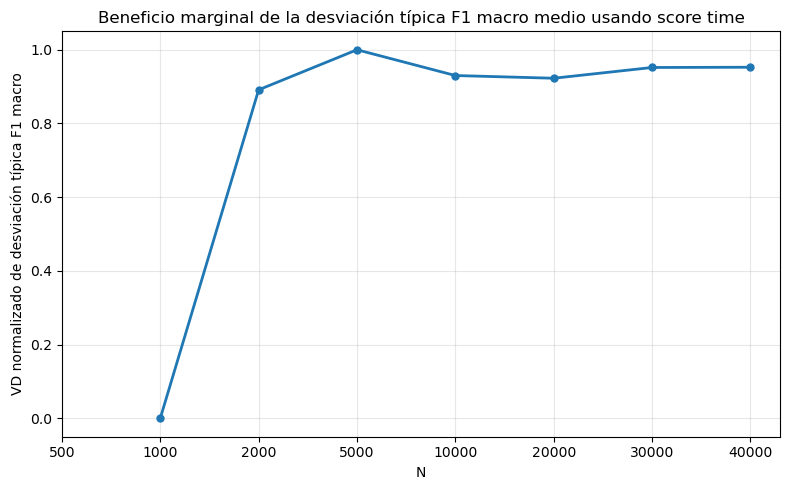

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_std_f1_macro_medio_con_score_time.pdf



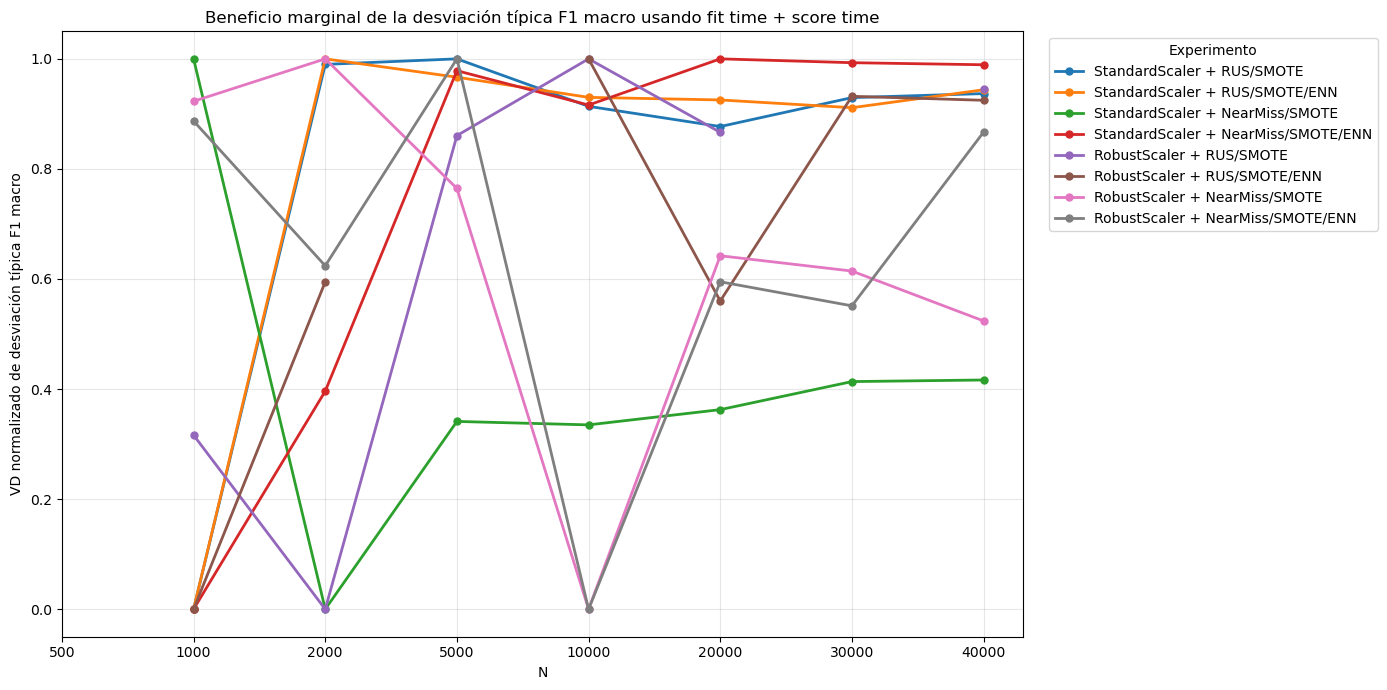

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_std_f1_macro_con_fit_score_time_por_experimento.pdf



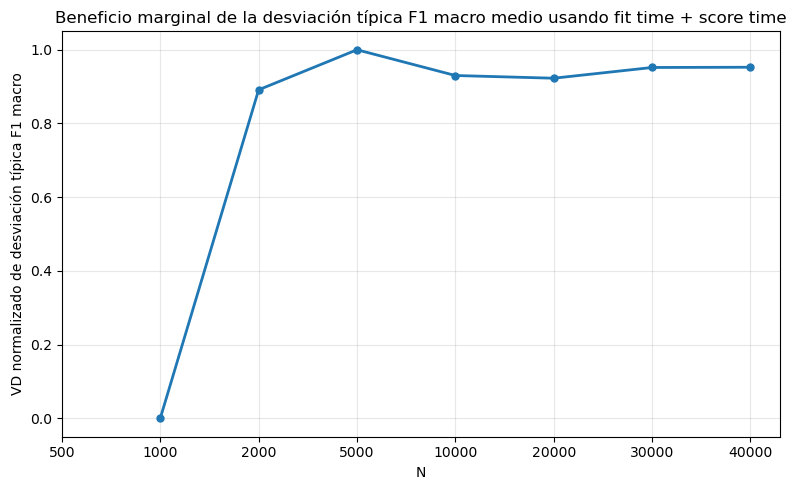

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_std_f1_macro_medio_con_fit_score_time.pdf



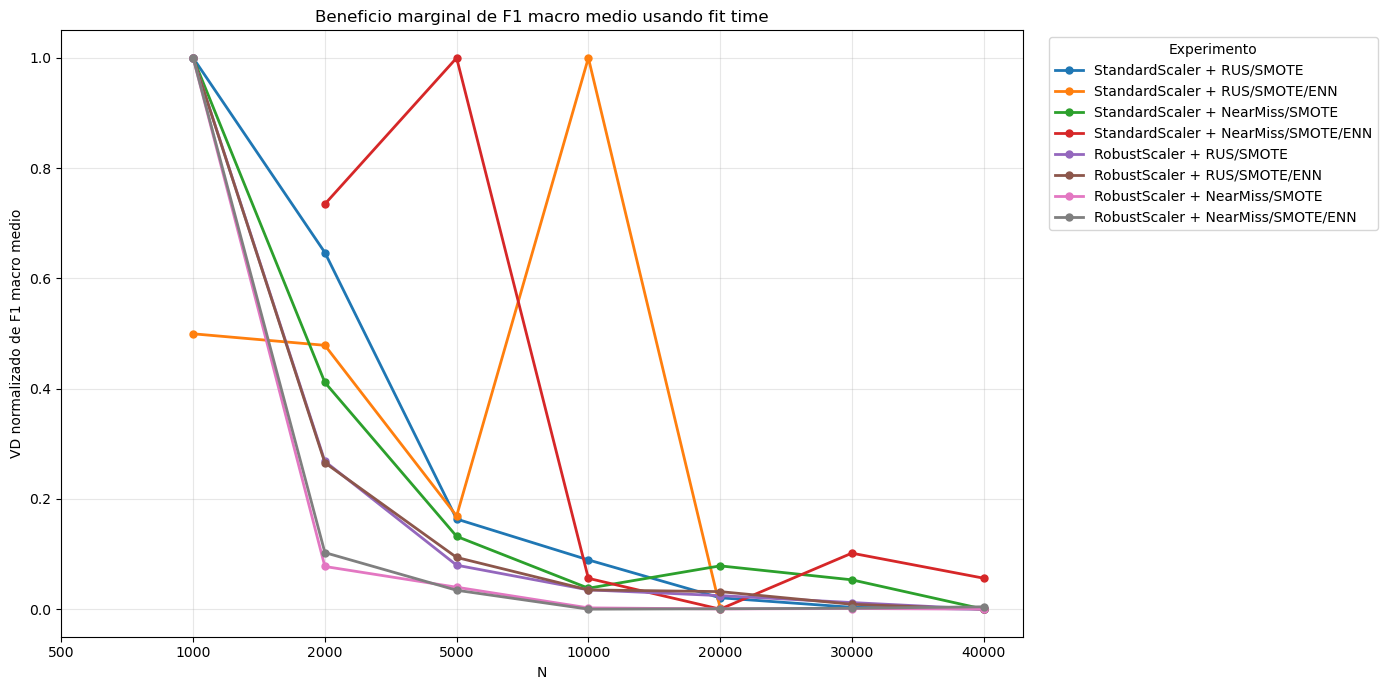

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_f1_macro_con_fit_time_por_experimento.pdf



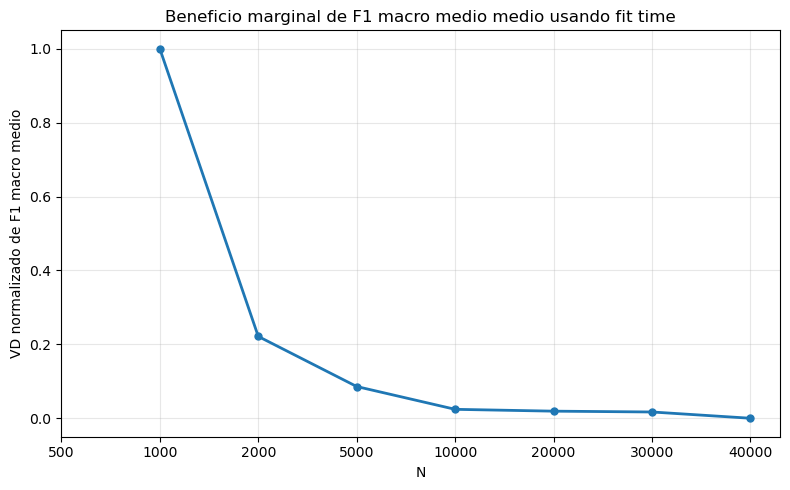

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_f1_macro_medio_con_fit_time.pdf



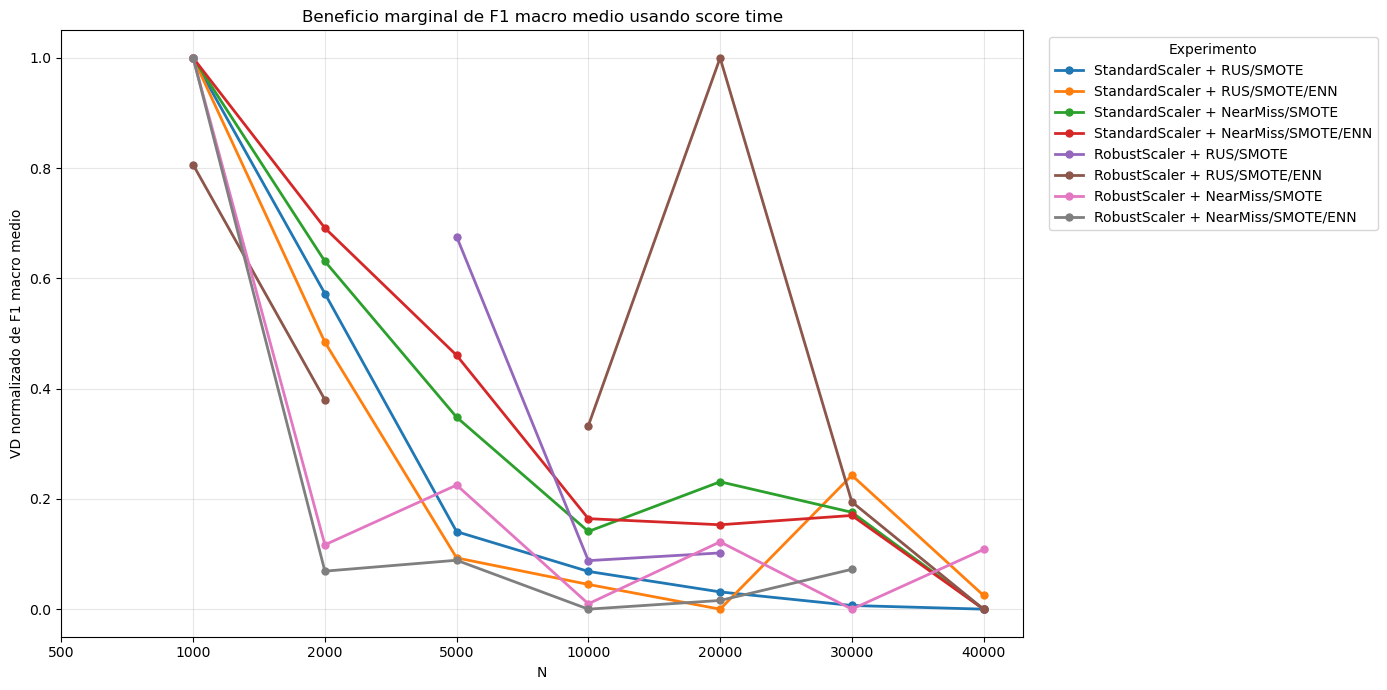

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_f1_macro_con_score_time_por_experimento.pdf



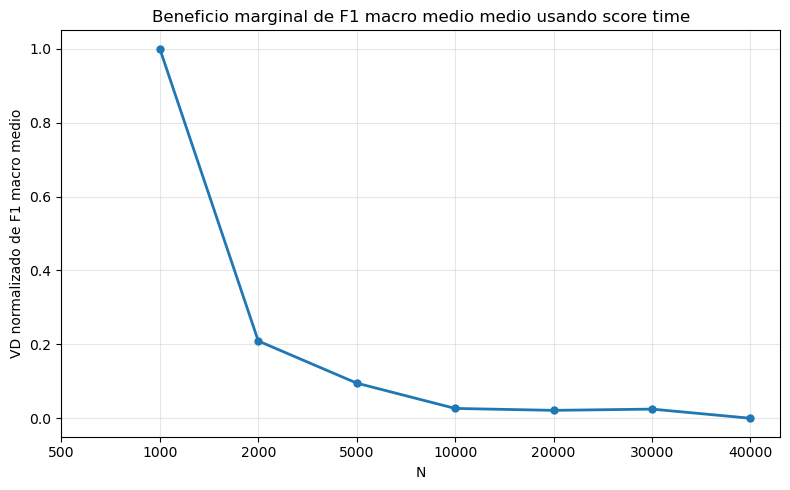

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_f1_macro_medio_con_score_time.pdf



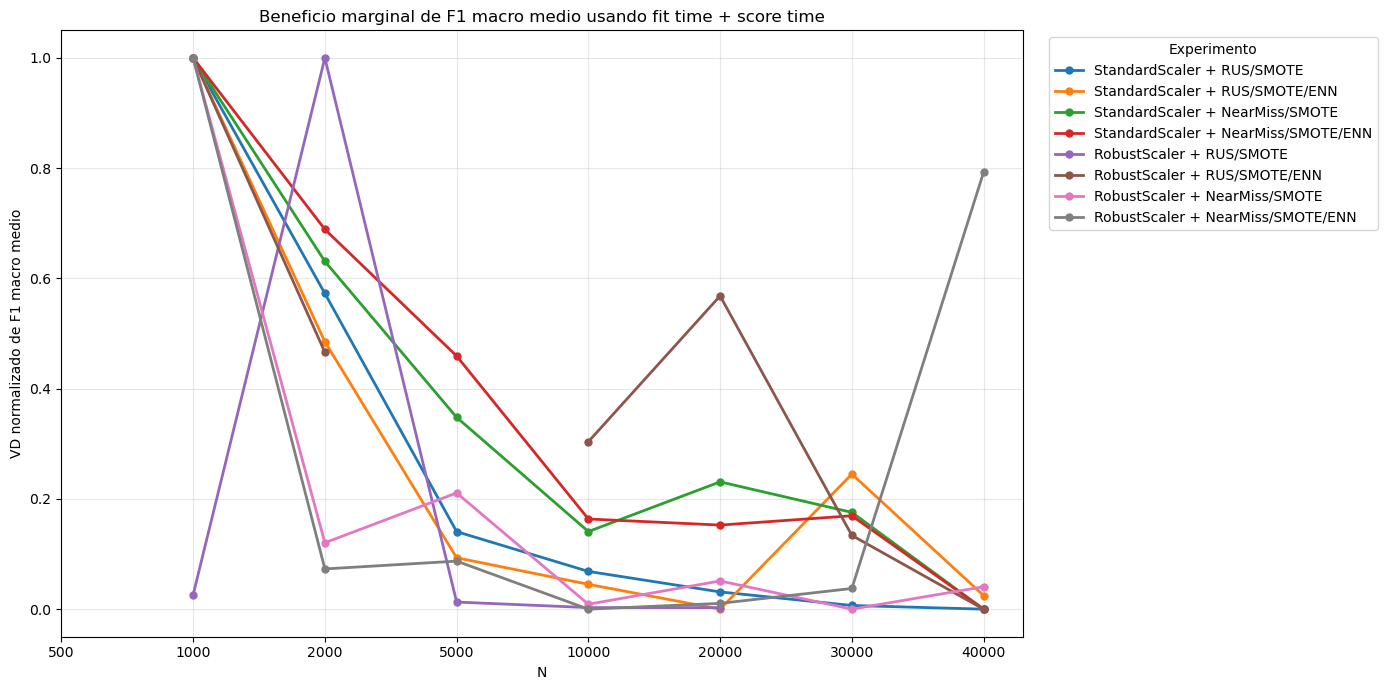

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_f1_macro_con_fit_score_time_por_experimento.pdf



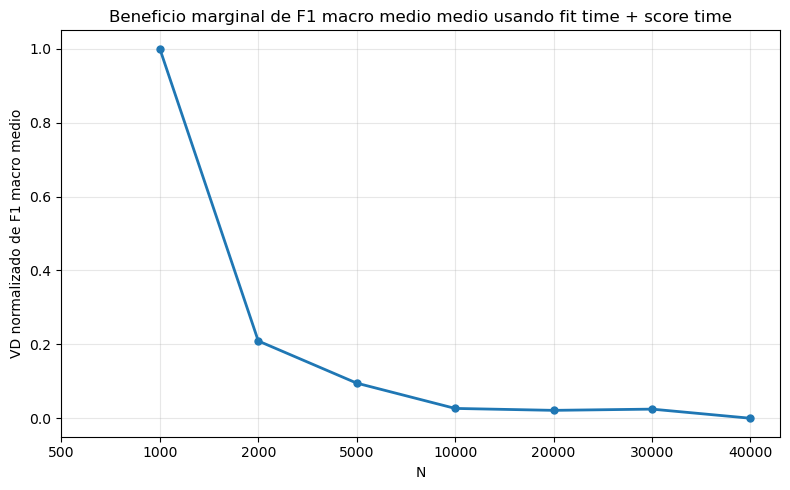

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_f1_macro_medio_con_fit_score_time.pdf



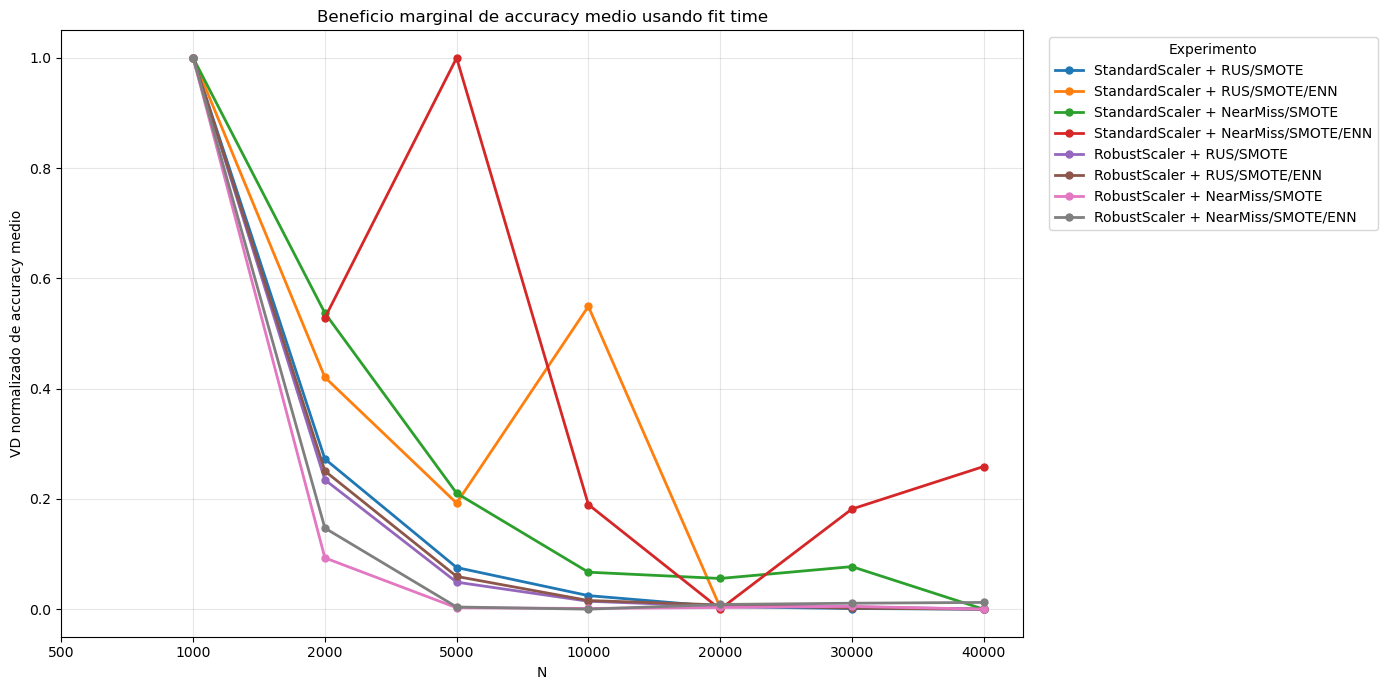

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_accuracy_con_fit_time_por_experimento.pdf



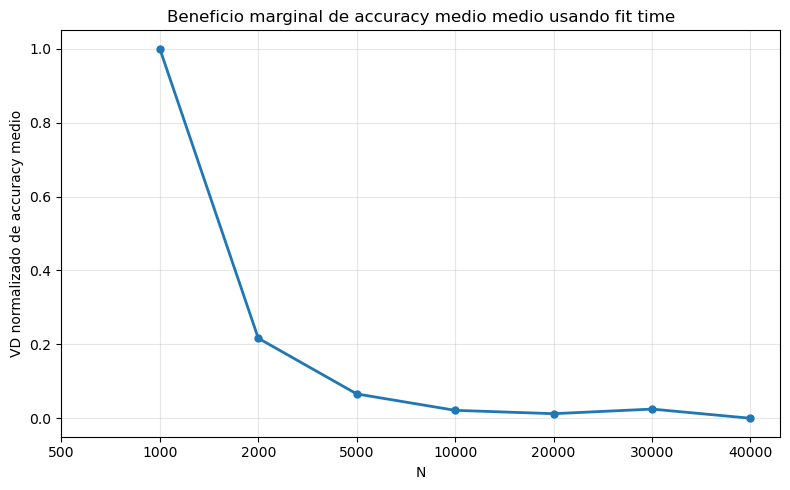

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_accuracy_medio_con_fit_time.pdf



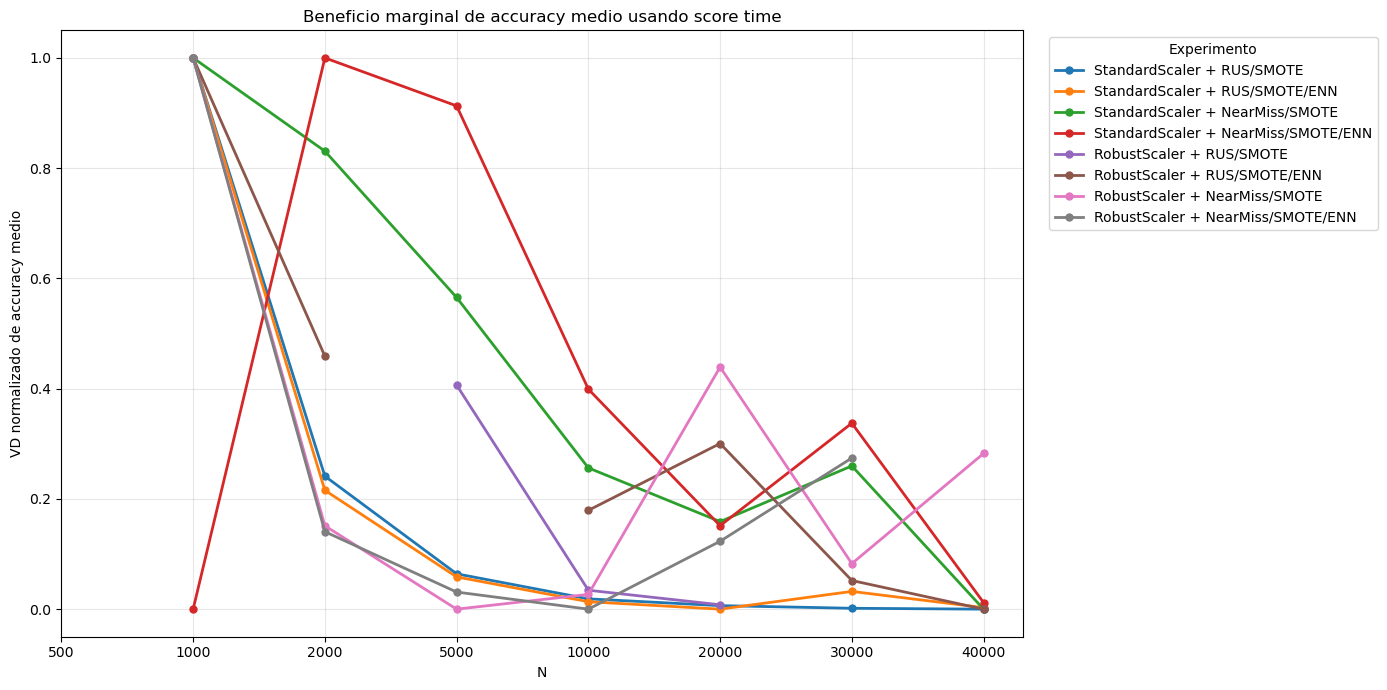

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_accuracy_con_score_time_por_experimento.pdf



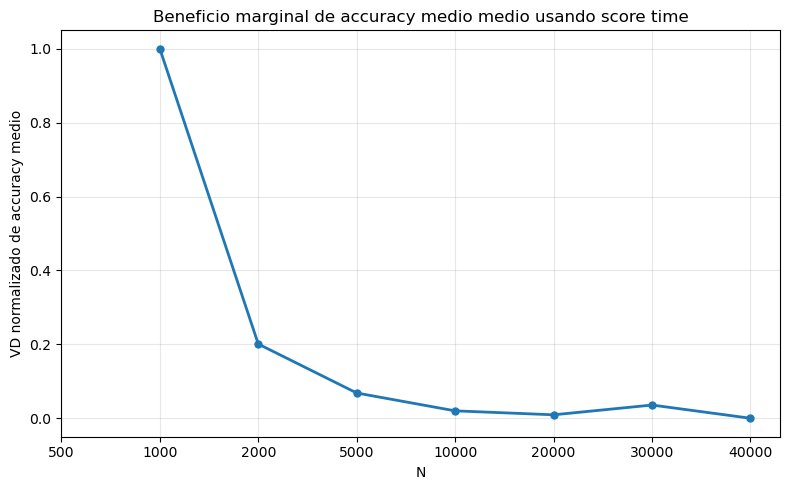

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_accuracy_medio_con_score_time.pdf



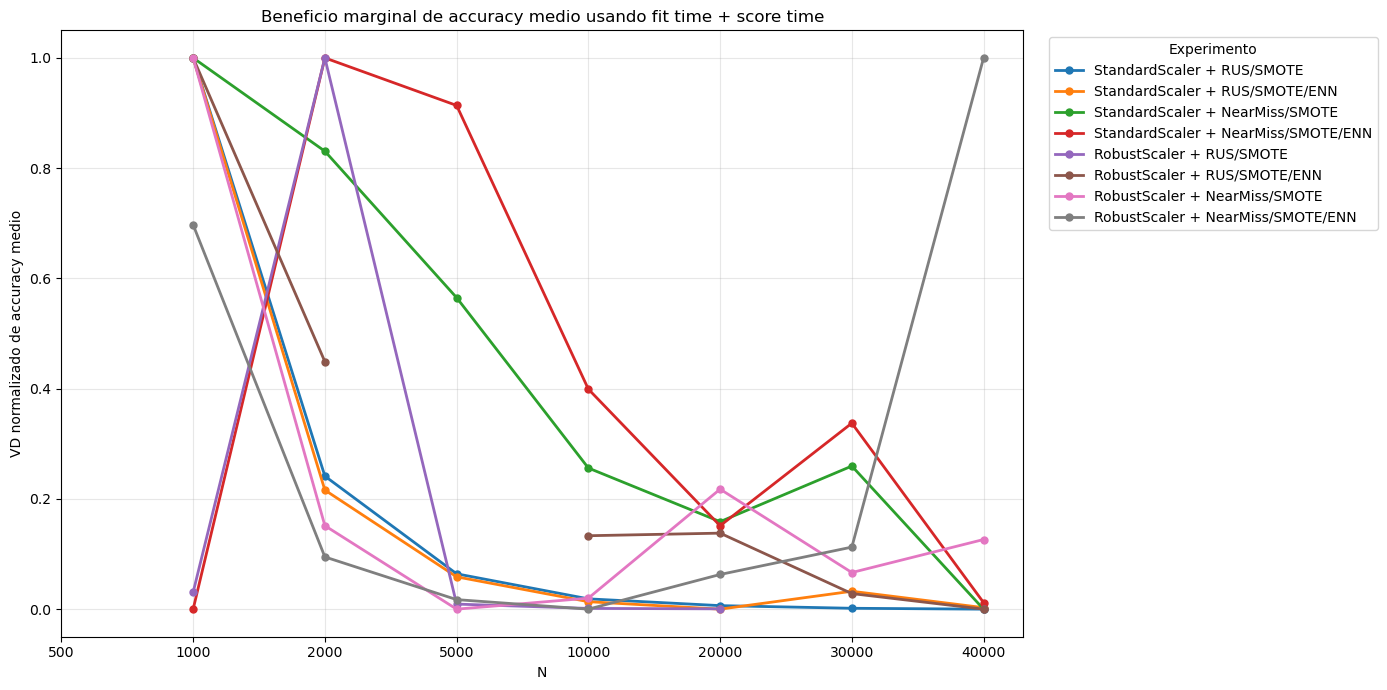

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_accuracy_con_fit_score_time_por_experimento.pdf



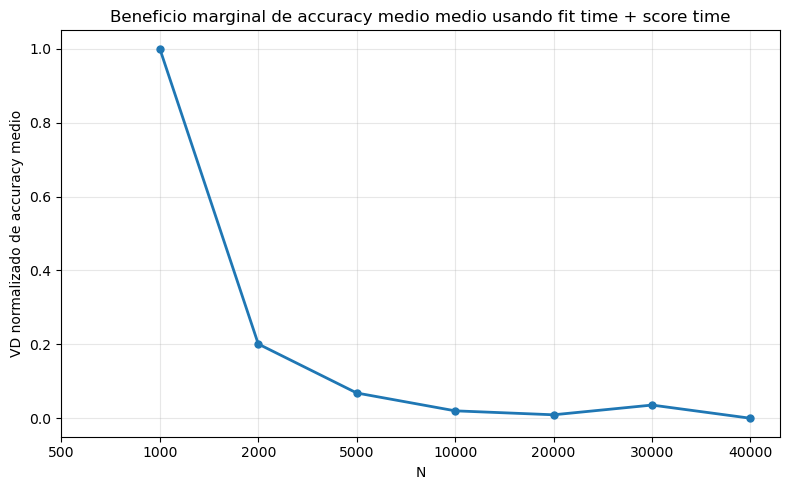

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC18/03_analisis/graficas/vd_media_accuracy_medio_con_fit_score_time.pdf



In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


RUTA_RESULTADOS = Path("resultados.csv")
RUTA_GRAFICAS = Path("graficas")
RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)

RUTA_TABLA_VD_EXPERIMENTOS = Path("tabla_vd_por_experimento.csv")
RUTA_TABLA_VD_MEDIAS = Path("tabla_vd_medias_experimentos.csv")

# El CSV tiene una primera fila de grupos y la cabecera real en la segunda fila.
df = pd.read_csv(RUTA_RESULTADOS, header=1)

# En el CSV el nombre del experimento solo aparece en la primera fila de cada bloque.
df["DESCRIPCIÓN EXPERIMENTO"] = df["DESCRIPCIÓN EXPERIMENTO"].ffill()

metricas = {
    "σ F1 MACRO": {
        "ylabel": "VD normalizado de desviación típica F1 macro",
        "titulo": "Beneficio marginal de la desviación típica F1 macro",
        "archivo": "vd_std_f1_macro",
    },
    "μ F1 MACRO": {
        "ylabel": "VD normalizado de F1 macro medio",
        "titulo": "Beneficio marginal de F1 macro medio",
        "archivo": "vd_media_f1_macro",
    },
    "μ ACCURACY": {
        "ylabel": "VD normalizado de accuracy medio",
        "titulo": "Beneficio marginal de accuracy medio",
        "archivo": "vd_media_accuracy",
    },
}

tiempos = {
    "fit_time": {
        "columna": "μ FIT TIME",
        "label": "fit time",
        "archivo": "fit_time",
    },
    "score_time": {
        "columna": "μ SCORE TIME",
        "label": "score time",
        "archivo": "score_time",
    },
    "total_time": {
        "columna": "μ TOTAL TIME",
        "label": "fit time + score time",
        "archivo": "fit_score_time",
    },
}

columnas_numericas = ["N", *metricas.keys(), "μ FIT TIME", "μ SCORE TIME"]
for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna])

df["μ TOTAL TIME"] = df["μ FIT TIME"] + df["μ SCORE TIME"]

n_values = sorted(df["N"].unique())
x_pos = np.arange(len(n_values))
mapa_x = dict(zip(n_values, x_pos))


def normalizar_serie(serie):
    serie = serie.astype(float)
    minimo = serie.min(skipna=True)
    maximo = serie.max(skipna=True)

    if pd.isna(minimo) or pd.isna(maximo) or np.isclose(maximo, minimo):
        return pd.Series(np.where(serie.notna(), 0.0, np.nan), index=serie.index)

    return (serie - minimo) / (maximo - minimo)


def calcular_tabla_vd(df_base, columnas_grupo):
    filas = []
    grupos = (
        df_base.groupby(columnas_grupo, sort=False, dropna=False)
        if columnas_grupo
        else [((), df_base)]
    )

    for claves_grupo, df_grupo in grupos:
        if not isinstance(claves_grupo, tuple):
            claves_grupo = (claves_grupo,)

        valores_grupo = dict(zip(columnas_grupo, claves_grupo))
        df_grupo = df_grupo.sort_values("N")

        for nombre_metrica in metricas:
            delta_metrica = df_grupo[nombre_metrica].diff()

            for nombre_tiempo, cfg_tiempo in tiempos.items():
                columna_tiempo = cfg_tiempo["columna"]
                delta_tiempo = df_grupo[columna_tiempo].diff()
                vd = delta_metrica / delta_tiempo.replace(0, np.nan)
                vd = vd.where(delta_tiempo > 0)
                vd_normalizado = normalizar_serie(vd)

                for idx, fila in df_grupo.iterrows():
                    filas.append({
                        **valores_grupo,
                        "N": fila["N"],
                        "métrica": nombre_metrica,
                        "tipo_tiempo": nombre_tiempo,
                        "tiempo": fila[columna_tiempo],
                        "valor_métrica": fila[nombre_metrica],
                        "delta_métrica": delta_metrica.loc[idx],
                        "delta_tiempo": delta_tiempo.loc[idx],
                        "VD": vd.loc[idx],
                        "VD_normalizado": vd_normalizado.loc[idx],
                    })

    return pd.DataFrame(filas)


def graficar_vd_por_experimento(tabla_vd, nombre_metrica, nombre_tiempo, cfg_metrica, cfg_tiempo):
    datos = tabla_vd[
        (tabla_vd["métrica"] == nombre_metrica)
        & (tabla_vd["tipo_tiempo"] == nombre_tiempo)
    ]

    plt.figure(figsize=(14, 7))

    for experimento, df_exp in datos.groupby("DESCRIPCIÓN EXPERIMENTO", sort=False):
        df_exp = df_exp.sort_values("N")
        plt.plot(
            df_exp["N"].map(mapa_x),
            df_exp["VD_normalizado"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=experimento,
        )

    plt.xticks(x_pos, [str(int(n)) for n in n_values])
    plt.ylim(-0.05, 1.05)
    plt.xlabel("N")
    plt.ylabel(cfg_metrica["ylabel"])
    plt.title(f"{cfg_metrica['titulo']} usando {cfg_tiempo['label']}")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Experimento", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    nombre_pdf = f"{cfg_metrica['archivo']}_con_{cfg_tiempo['archivo']}_por_experimento.pdf"
    ruta_salida = RUTA_GRAFICAS / nombre_pdf
    plt.savefig(ruta_salida, bbox_inches="tight")
    plt.show()

    print("Gráfica guardada en:")
    print(ruta_salida.resolve())
    print()


def graficar_vd_medias(tabla_vd_medias, nombre_metrica, nombre_tiempo, cfg_metrica, cfg_tiempo):
    datos = tabla_vd_medias[
        (tabla_vd_medias["métrica"] == nombre_metrica)
        & (tabla_vd_medias["tipo_tiempo"] == nombre_tiempo)
    ].sort_values("N")

    plt.figure(figsize=(8, 5))
    plt.plot(
        datos["N"].map(mapa_x),
        datos["VD_normalizado"],
        marker="o",
        linewidth=2,
        markersize=5,
    )

    plt.xticks(x_pos, [str(int(n)) for n in n_values])
    plt.ylim(-0.05, 1.05)
    plt.xlabel("N")
    plt.ylabel(cfg_metrica["ylabel"])
    plt.title(f"{cfg_metrica['titulo']} medio usando {cfg_tiempo['label']}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    nombre_pdf = f"{cfg_metrica['archivo']}_medio_con_{cfg_tiempo['archivo']}.pdf"
    ruta_salida = RUTA_GRAFICAS / nombre_pdf
    plt.savefig(ruta_salida, bbox_inches="tight")
    plt.show()

    print("Gráfica guardada en:")
    print(ruta_salida.resolve())
    print()


tabla_vd_experimentos = calcular_tabla_vd(df, ["DESCRIPCIÓN EXPERIMENTO"])
tabla_vd_experimentos.to_csv(RUTA_TABLA_VD_EXPERIMENTOS, index=False)

columnas_media = ["N", *metricas.keys(), "μ FIT TIME", "μ SCORE TIME", "μ TOTAL TIME"]
df_medias = df[columnas_media].groupby("N", as_index=False).mean()
tabla_vd_medias = calcular_tabla_vd(df_medias, [])
tabla_vd_medias.to_csv(RUTA_TABLA_VD_MEDIAS, index=False)

print("Tabla VD por experimento guardada en:")
print(RUTA_TABLA_VD_EXPERIMENTOS.resolve())
print()
print("Tabla VD con medias de experimentos guardada en:")
print(RUTA_TABLA_VD_MEDIAS.resolve())
print()

# Por cada métrica se generan tres gráficas: fit time, score time y fit time + score time.
for nombre_metrica, cfg_metrica in metricas.items():
    for nombre_tiempo, cfg_tiempo in tiempos.items():
        graficar_vd_por_experimento(
            tabla_vd_experimentos,
            nombre_metrica,
            nombre_tiempo,
            cfg_metrica,
            cfg_tiempo,
        )
        graficar_vd_medias(
            tabla_vd_medias,
            nombre_metrica,
            nombre_tiempo,
            cfg_metrica,
            cfg_tiempo,
        )
